# AAI614: Data Science & its Applications

*Notebook 5.4: Experiment with KNN*

Extended all three examples beyond a single train/test split.

**Example 1 (Social Network Ads) and Example 2 (Digits)** originally used an arbitrary k; I added 5-fold cross-validation, a validation curve, and `GridSearchCV` to tune `n_neighbors`, `weights`, and distance metric (Digits improved to 98.9%; also removed a duplicate cell).

Added my own **Example 3 (Breast Cancer)**, my own addition, applies the full toolkit—cross-validation, validation curve, learning curve, and grid search—plus precision/recall and ROC-AUC (**0.973**), which matter when false negatives are costly. This demonstrates the bias–variance tradeoff and proper hyperparameter selection.

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-5/Saoud-Notebook5.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Example I: Classifying Social Networks Ads

## Importing the libraries

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [30]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

dataset = pd.read_csv('https://raw.githubusercontent.com/techseeko/AAI614_Haidar/refs/heads/main/Week-5/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

## Splitting the dataset into the Training set and Test set

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


## Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Fitting K-NN to the Training set

Use the KNN model for training by specifying the input and output variables of the training set as follows.  Note that *p =2* refers to **euclidean distance**.

In [33]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

## Predicting the Test set results

In [34]:
y_pred = classifier.predict(X_test)

## Making the Confusion Matrix

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[64,  4],
       [ 3, 29]])

## Optimizing Example I

The model above used an arbitrary `k = 5` and was judged on a single train/test split. Following the lessons in week 5, we now (a) get a more reliable estimate with **cross-validation**, (b) pick the best `k` from a **validation curve**, and (c) tune all hyperparameters with **grid search**.

k=5  ->  5-fold CV accuracy: 0.903 (+/- 0.046)


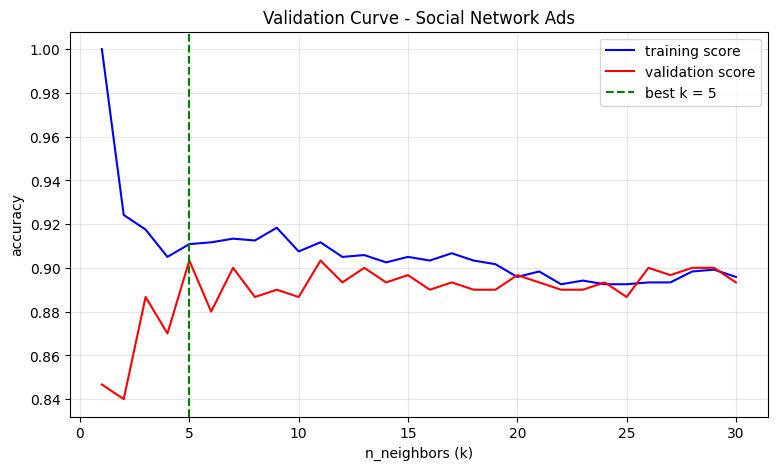


Best params: {'n_neighbors': np.int64(6), 'p': 2, 'weights': 'distance'}
Best CV accuracy: 0.907
Tuned model test accuracy:    0.930
Original k=5 test accuracy:   0.930


In [36]:
from sklearn.model_selection import cross_val_score, validation_curve, GridSearchCV

# (a) Cross-validation of the original k=5 model
cv_scores = cross_val_score(classifier, X_train, y_train, cv=5)
print("k=5  ->  5-fold CV accuracy: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std()))

# (b) Validation curve: training vs. validation accuracy across k
k_range = np.arange(1, 31)
train_score, val_score = validation_curve(
    KNeighborsClassifier(), X_train, y_train,
    param_name='n_neighbors', param_range=k_range, cv=5)

best_k = k_range[np.argmax(np.mean(val_score, axis=1))]

plt.figure(figsize=(9, 5))
plt.plot(k_range, np.mean(train_score, axis=1), color='blue', label='training score')
plt.plot(k_range, np.mean(val_score, axis=1), color='red', label='validation score')
plt.axvline(best_k, color='green', linestyle='--', label='best k = {}'.format(best_k))
plt.xlabel('n_neighbors (k)')
plt.ylabel('accuracy')
plt.title('Validation Curve - Social Network Ads')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# (c) Grid search over k, weighting scheme and distance metric
param_grid = {'n_neighbors': np.arange(1, 31), 'weights': ['uniform', 'distance'], 'p': [1, 2]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV accuracy: {:.3f}".format(grid.best_score_))
print("Tuned model test accuracy:    {:.3f}".format(grid.best_estimator_.score(X_test, y_test)))
print("Original k=5 test accuracy:   {:.3f}".format(classifier.score(X_test, y_test)))

# Example II: Classifying Digits

In [37]:
from sklearn import metrics

In [38]:
from sklearn.datasets import load_digits
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [39]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [40]:
#Predict Output
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(x_test))
score = model.score(x_test, y_test)

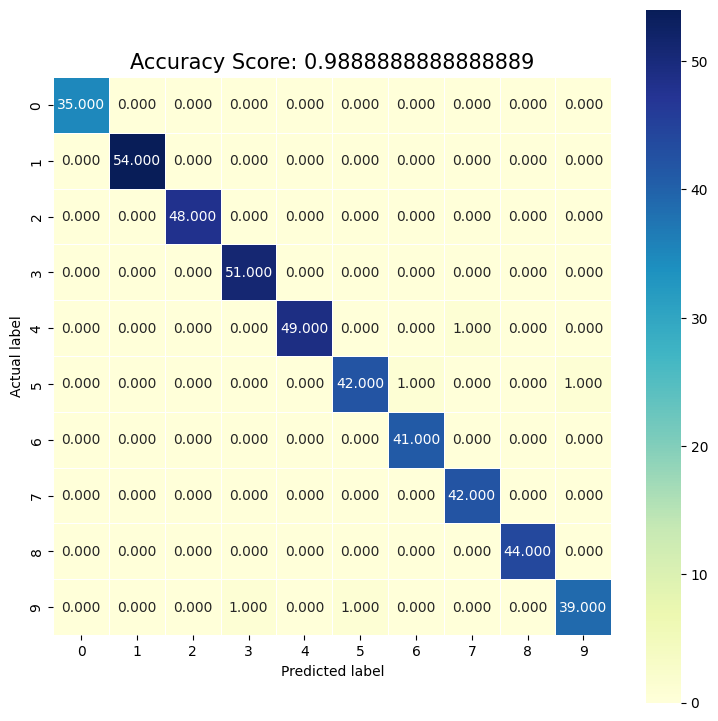

In [41]:
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5,square = True, cmap = 'YlGnBu')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);

## Optimizing Example II

The digits model used an arbitrary `k = 3` on a single split. We validate it with **cross-validation** and let **grid search** find the best `k` and weighting scheme.

In [42]:
# Cross-validate the original k=3 model
cv_scores_digits = cross_val_score(KNeighborsClassifier(n_neighbors=3), x_train, y_train, cv=5)
print("k=3  ->  5-fold CV accuracy: {:.3f} (+/- {:.3f})".format(
    cv_scores_digits.mean(), cv_scores_digits.std()))

# Grid search over k and weighting scheme
param_grid_digits = {'n_neighbors': np.arange(1, 21), 'weights': ['uniform', 'distance']}
grid_digits = GridSearchCV(KNeighborsClassifier(), param_grid_digits, cv=5, scoring='accuracy')
grid_digits.fit(x_train, y_train)

print("\nBest params:", grid_digits.best_params_)
print("Best CV accuracy: {:.3f}".format(grid_digits.best_score_))
print("Tuned model test accuracy:  {:.3f}".format(grid_digits.best_estimator_.score(x_test, y_test)))
print("Original k=3 test accuracy: {:.3f}".format(score))

k=3  ->  5-fold CV accuracy: 0.984 (+/- 0.004)

Best params: {'n_neighbors': np.int64(2), 'weights': 'distance'}
Best CV accuracy: 0.989
Tuned model test accuracy:  0.993
Original k=3 test accuracy: 0.989


# Example III: Breast Cancer Diagnosis

Here we apply KNN to the built-in **Breast Cancer Wisconsin** dataset from *sklearn*. It contains 569 tumor samples described by 30 numeric features (radius, texture, perimeter, area, smoothness, etc.), and the task is to classify each tumor as **malignant** or **benign**.

In a medical diagnostic setting, overall accuracy is not enough — a *false negative* (missing a malignant tumor) is far more dangerous than a false positive. So we focus on **precision, recall, and ROC-AUC** in addition to accuracy.

In [43]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c = cancer.data
y_c = cancer.target  # 0 = malignant, 1 = benign

print("Data shape:", X_c.shape)
print("Target classes:", cancer.target_names)
print("Class distribution:", np.bincount(y_c))

# Split into training and test sets (stratified to keep class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.25, random_state=0, stratify=y_c
)

Data shape: (569, 30)
Target classes: ['malignant' 'benign']
Class distribution: [212 357]


In [44]:
# Feature scaling: essential for KNN since features have very different ranges
sc_cancer = StandardScaler()
X_train_c = sc_cancer.fit_transform(X_train_c)
X_test_c = sc_cancer.transform(X_test_c)

# Train KNN classifier
cancer_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
cancer_clf.fit(X_train_c, y_train_c)

y_pred_c = cancer_clf.predict(X_test_c)
print("Test accuracy: {:.3f}".format(cancer_clf.score(X_test_c, y_test_c)))

Test accuracy: 0.951


## Evaluating with precision, recall, and the confusion matrix

For diagnosis we care most about **recall for the malignant class** — the fraction of actual malignant tumors the model correctly catches. A missed malignant case (false negative) is the most costly error.

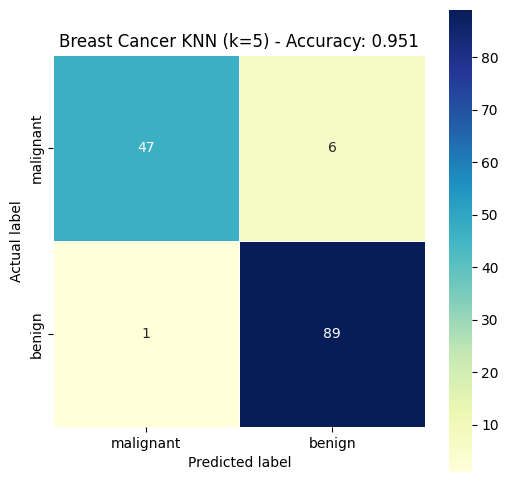

              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        53
      benign       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



In [45]:
from sklearn.metrics import classification_report

cm_cancer = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_cancer, annot=True, fmt="d", linewidths=.5, square=True, cmap='YlGnBu',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Breast Cancer KNN (k=5) - Accuracy: {:.3f}'.format(cancer_clf.score(X_test_c, y_test_c)))
plt.show()

print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

## ROC curve and AUC

The ROC curve shows the trade-off between the true positive rate and false positive rate across all decision thresholds. The **AUC** (area under the curve) summarizes this in a single number, where 1.0 is perfect and 0.5 is random guessing. We use the predicted probability of the malignant class.

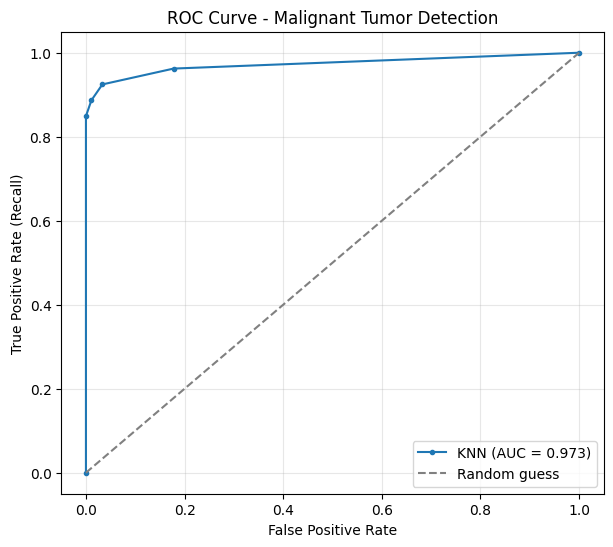

ROC-AUC: 0.973


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

# Treat "malignant" (class 0) as the positive class of interest
malignant_idx = list(cancer.target_names).index('malignant')
y_scores = cancer_clf.predict_proba(X_test_c)[:, malignant_idx]

fpr, tpr, thresholds = roc_curve(y_test_c, y_scores, pos_label=malignant_idx)
auc = roc_auc_score((y_test_c == malignant_idx).astype(int), y_scores)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, marker='.', label='KNN (AUC = {:.3f})'.format(auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Malignant Tumor Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ROC-AUC: {:.3f}".format(auc))

# Validating the Hyperparameter *k*

So far we evaluated KNN on a single train/test split. As the lessons in week 5 stressed, a single holdout split can be misleading — a more robust estimate comes from **cross-validation**, and the best hyperparameter should be chosen with a **validation curve**, a **learning curve**, and finally an automated **grid search**. Here we apply each of those tools to KNN's main knob, `n_neighbors` (*k*).

## 1. Cross-validation

Instead of trusting one split, we use 5-fold cross-validation (`cross_val_score`) to get a more reliable estimate of accuracy and its variability.

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(cancer_clf, X_train_c, y_train_c, cv=5)
print("5-fold CV accuracies:", np.round(cv_scores, 3))
print("Mean CV accuracy: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std()))

5-fold CV accuracies: [0.942 0.976 0.941 0.988 0.953]
Mean CV accuracy: 0.960 (+/- 0.019)


## 2. Validation curve for *k*

The validation curve plots the training and cross-validated scores as we vary a single hyperparameter. For KNN, **small *k* = high variance/overfitting** (high train score, lower validation score) and **large *k* = high bias/underfitting** (both scores drop). The best *k* sits where the validation score peaks.

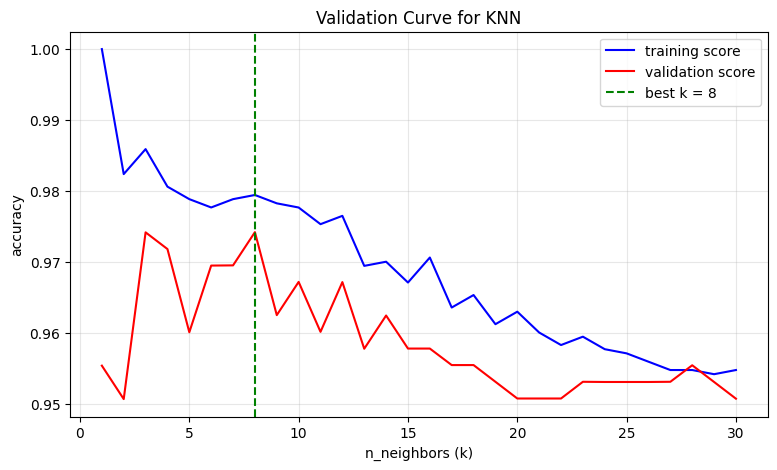

Best k from validation curve: 8


In [48]:
from sklearn.model_selection import validation_curve

k_range = np.arange(1, 31)
train_score, val_score = validation_curve(
    KNeighborsClassifier(), X_train_c, y_train_c,
    param_name='n_neighbors', param_range=k_range, cv=5)

plt.figure(figsize=(9, 5))
plt.plot(k_range, np.mean(train_score, axis=1), color='blue', label='training score')
plt.plot(k_range, np.mean(val_score, axis=1), color='red', label='validation score')
best_k = k_range[np.argmax(np.mean(val_score, axis=1))]
plt.axvline(best_k, color='green', linestyle='--', label='best k = {}'.format(best_k))
plt.xlabel('n_neighbors (k)')
plt.ylabel('accuracy')
plt.title('Validation Curve for KNN')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print("Best k from validation curve:", best_k)

## 3. Learning curve

The learning curve shows how the training and validation scores evolve as the training set grows. If the two curves have converged, adding more data won't help; a persistent gap indicates the model could benefit from more data or lower complexity.

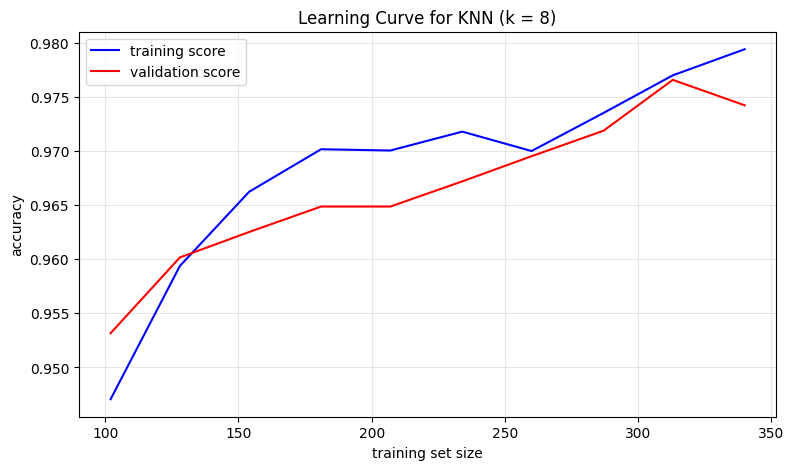

In [49]:
from sklearn.model_selection import learning_curve

N, train_lc, val_lc = learning_curve(
    KNeighborsClassifier(n_neighbors=best_k), X_train_c, y_train_c,
    cv=5, train_sizes=np.linspace(0.3, 1.0, 10))

plt.figure(figsize=(9, 5))
plt.plot(N, np.mean(train_lc, axis=1), color='blue', label='training score')
plt.plot(N, np.mean(val_lc, axis=1), color='red', label='validation score')
plt.xlabel('training set size')
plt.ylabel('accuracy')
plt.title('Learning Curve for KNN (k = {})'.format(best_k))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Grid search

Real models have several hyperparameters. `GridSearchCV` automatically cross-validates every combination and keeps the best. Here we tune `n_neighbors`, `weights` (uniform vs. distance-weighted voting), and `p` (Manhattan vs. Euclidean distance), then evaluate the best model on the held-out test set.

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # 1 = Manhattan, 2 = Euclidean
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_c, y_train_c)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy: {:.3f}".format(grid.best_score_))

# Evaluate the tuned model on the untouched test set
best_model = grid.best_estimator_
print("Test accuracy of tuned model: {:.3f}".format(best_model.score(X_test_c, y_test_c)))

Best parameters: {'n_neighbors': np.int64(4), 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.979
Test accuracy of tuned model: 0.958
